# 04 · Kuramoto phase synchronization

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/D2718281828nis/neuro-GAT-Kuramoto-NeuroODE/blob/main/examples/notebooks/04_kuramoto_sync.ipynb)

The classic Kuramoto model couples oscillator *phases* through a sine of
their pairwise difference:

```
d(theta_i)/dt = omega_i + K * mean_j sin(theta_j - theta_i)
```

Synchronization is measured by the **order parameter**
`r = |mean_j exp(i * theta_j)|`, which goes from 0 (phases spread evenly
around the circle) to 1 (all phases equal). This is exactly the mechanism
behind latent coordinate 0 in the full model — see
`KuramotoGrandVectorField.forward`'s `kur[:, 0]` term — restricted here to
a small subgraph so the dynamics are easy to see on their own.

In [1]:
# --- Setup -------------------------------------------------------------
# Makes the project importable whether this notebook runs standalone in
# Google Colab or from a local checkout, then imports the shared libraries
# used throughout. Safe to re-run.
import os
import sys
import subprocess

REPO_URL = "https://github.com/D2718281828nis/neuro-GAT-Kuramoto-NeuroODE.git"


def _locate_repo():
    for candidate in (".", "..", "../..", "repo"):
        path = os.path.abspath(candidate)
        if os.path.isdir(os.path.join(path, "hmb_kuramoto_ode")):
            return path
    # A sparse, blobless clone: this repository also bundles a ~490 MB STEW
    # dataset/ folder (see notebook 07), which this notebook does not need.
    subprocess.run(
        ["git", "clone", "--quiet", "--depth", "1", "--filter=blob:none",
         "--no-checkout", "--sparse", REPO_URL, "repo"],
        check=True,
    )
    subprocess.run(["git", "-C", "repo", "sparse-checkout", "init", "--cone"], check=True)
    subprocess.run(
        ["git", "-C", "repo", "sparse-checkout", "set", "hmb_kuramoto_ode", "examples", "configs", "pyproject.toml"],
        check=True,
    )
    subprocess.run(["git", "-C", "repo", "checkout", "--quiet"], check=True)
    return os.path.abspath("repo")


REPO_DIR = _locate_repo()
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q",
     "torch>=2.5,<3", "numpy>=2,<3", "scipy>=1.14,<2", "scikit-learn>=1.5,<2", "matplotlib>=3.9,<4"],
    check=True,
)

import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt
from hmb_kuramoto_ode.utils.seed import seed_everything

print(f"repository: {REPO_DIR}")
print(f"torch {torch.__version__} | CUDA available: {torch.cuda.is_available()}")


repository: /Users/denmacair/Documents/code_base/neuro-GAT-Kuramoto-NeuroODE
torch 2.13.0 | CUDA available: False


In [2]:
from hmb_kuramoto_ode.data.graph_builder import build_hierarchical_graph, SPATIAL_SAME_BAND

REGIONS = 8
edge_index, edge_types = build_hierarchical_graph(REGIONS)
ALPHA_BAND = 2  # delta=0, theta=1, alpha=2, beta=3, gamma=4

# Keep only the same-band spatial edges of the alpha rhythm, and collapse
# "electrode*5 + band" node indices down to one index per electrode: this
# reproduces the real same-band spatial coupling structure (electrodes in a
# chain) restricted to a single rhythm, giving a clean set of oscillators.
mask = (edge_types == SPATIAL_SAME_BAND) & (edge_index[0] % 5 == ALPHA_BAND)
kuramoto_edges = edge_index[:, mask] // 5
n = REGIONS
print(f"{n} coupled alpha-band oscillators (one per electrode), {kuramoto_edges.shape[1]} directed couplings")


8 coupled alpha-band oscillators (one per electrode), 14 directed couplings


In [3]:
def order_parameter(phase):
    z = torch.complex(torch.cos(phase), torch.sin(phase))
    return z.mean().abs().item()


def kuramoto_step(phase, edges, omega, K, dt=0.05):
    src, dst = edges
    coupling = torch.zeros_like(phase)
    coupling.index_add_(0, dst, torch.sin(phase[src] - phase[dst]))
    degree = torch.zeros_like(phase).index_add_(0, dst, torch.ones_like(dst, dtype=phase.dtype))
    coupling = coupling / degree.clamp(min=1)
    return phase + dt * (omega + K * coupling)


## Coupling strength controls synchronization

Below the same natural frequencies `omega` are simulated under four
coupling strengths `K`. Weak coupling never synchronizes; strong coupling
locks all oscillators to a common phase — the same phase transition studied
in the original Kuramoto model.

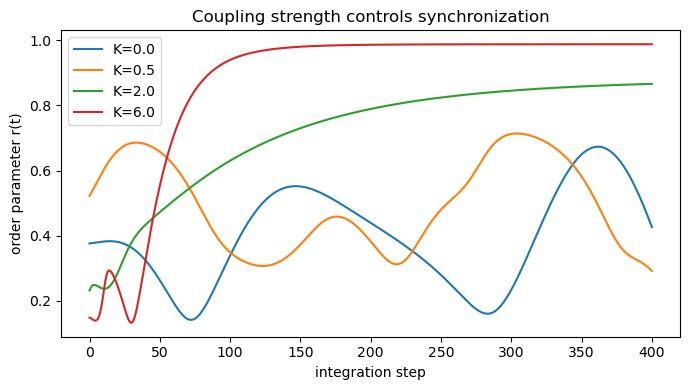

In [4]:
seed_everything(7)
omega = torch.randn(n) * 0.5
STEPS = 400
results = {}
for K in (0.0, 0.5, 2.0, 6.0):
    phase = torch.rand(n) * 2 * torch.pi
    trace = [order_parameter(phase)]
    for _ in range(STEPS):
        phase = kuramoto_step(phase, kuramoto_edges, omega, K)
        trace.append(order_parameter(phase))
    results[K] = trace

fig, ax = plt.subplots(figsize=(7, 4))
for K, trace in results.items():
    ax.plot(trace, label=f"K={K}")
ax.set(xlabel="integration step", ylabel="order parameter r(t)",
       title="Coupling strength controls synchronization")
ax.legend()
fig.tight_layout()
plt.show()


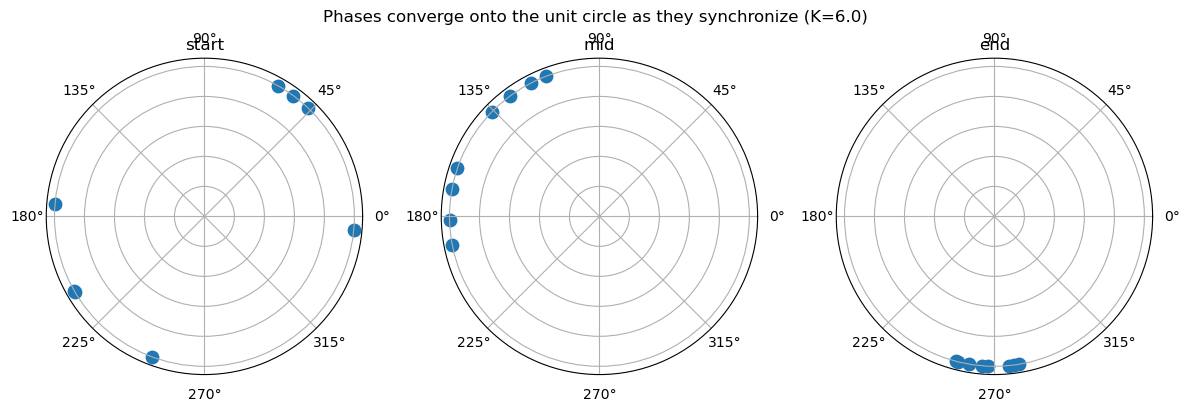

In [5]:
K = 6.0
seed_everything(11)
phase = torch.rand(n) * 2 * torch.pi
snap_at = {0: "start", 40: "mid", 400: "end"}
snapshots = {snap_at[0]: phase.clone()}
for step in range(1, 401):
    phase = kuramoto_step(phase, kuramoto_edges, omega, K=K)
    if step in snap_at:
        snapshots[snap_at[step]] = phase.clone()

fig, axes = plt.subplots(1, 3, figsize=(12, 4), subplot_kw={"projection": "polar"})
for ax, (name, ph) in zip(axes, snapshots.items()):
    ax.scatter(ph.numpy(), np.ones(n), s=80)
    ax.set_title(name)
    ax.set_yticklabels([])
fig.suptitle(f"Phases converge onto the unit circle as they synchronize (K={K})")
fig.tight_layout()
plt.show()


## Bridging to the project's differentiable solver

The manual Euler loop above is a teaching simplification. The real model
integrates its dynamics with `hmb_kuramoto_ode.models.ode_solver.integrate`,
which supports both Euler and a differentiable RK4 and keeps every
intermediate state on the autograd graph. Wrapping the same coupling rule as
a `field(t, phase)` function lets us run it through that exact solver.

order parameter after RK4 integration: 0.9878


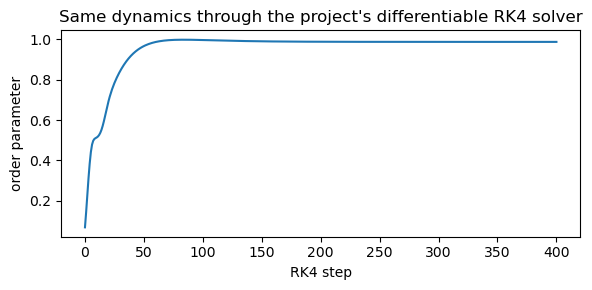

In [6]:
from hmb_kuramoto_ode.models.ode_solver import integrate


def kuramoto_field(t, phase):
    src, dst = kuramoto_edges
    coupling = torch.zeros_like(phase)
    coupling.index_add_(0, dst, torch.sin(phase[src] - phase[dst]))
    degree = torch.zeros_like(phase).index_add_(0, dst, torch.ones_like(dst, dtype=phase.dtype))
    return omega + K * coupling / degree.clamp(min=1)


seed_everything(11)
phase0 = torch.rand(n) * 2 * torch.pi
final_phase, trajectory = integrate(kuramoto_field, phase0, t1=20.0, step_size=0.05, method="rk4", return_trajectory=True)
r_trace = [order_parameter(p) for p in trajectory]
print(f"order parameter after RK4 integration: {r_trace[-1]:.4f}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(r_trace)
ax.set(xlabel="RK4 step", ylabel="order parameter",
       title="Same dynamics through the project's differentiable RK4 solver")
fig.tight_layout()
plt.show()


## Key takeaway

Kuramoto coupling only ever touches the angular coordinate, and only
through a sine of the pairwise phase difference — never a linear average.
That is precisely why the full model keeps it separate from the GRAND
diffusion of notebook 03, and combines the two with a learned gate rather
than one generic mixing rule (notebook 06).